In [33]:
import pandas as pd
import numpy as np 


df_vendas = pd.read_csv('vendas_tech.csv', low_memory=False)
df_gerentes = pd.read_excel('gerentes_lojas.xlsx')

display(df_vendas)

display(df_vendas.columns)
display(df_vendas.info())




,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Data_Base
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095,2025-01-01
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750,NaN
2,3,2023-02-25,NaN,"Monitor 27""",1200.0,1,Cliente_14859,NaN
3,4,2024-11-19,RIO DE JANEIRO,Mouse Gamer,120.0,2,Cliente_17343,NaN
4,5,2024-01-27,Rio de Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,NaN
...,...,...,...,...,...,...,...,...
100095,94091,2023-10-20,Porto Alegre,iPhone 14,5500.0,1,Cliente_11755,NaN
100096,52883,2024-03-17,Porto Alegre,Notebook Dell,3500.0,2,Cliente_12879,NaN
100097,65070,2023-06-19,Belo Horizonte,Smartphone Samsung,2200.0,2,Cliente_8160,NaN
100098,94031,2024-06-14,Salvador,iPhone 14,5500.0,2,Cliente_28545,NaN


Index(['ID_Pedido', 'Data', 'Loja', 'Produto', 'Preco_Unitario', 'Qtd',
       'Cliente', 'Data_Base'],
      dtype='str')

<class 'pandas.DataFrame'>
RangeIndex: 100100 entries, 0 to 100099
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   ID_Pedido       100100 non-null  int64  
 1   Data            100100 non-null  str    
 2   Loja            98099 non-null   str    
 3   Produto         100100 non-null  str    
 4   Preco_Unitario  100100 non-null  float64
 5   Qtd             100100 non-null  int64  
 6   Cliente         100100 non-null  str    
 7   Data_Base       1 non-null       str    
dtypes: float64(1), int64(2), str(5)
memory usage: 6.1 MB


None

In [34]:
#Tratamento de dados

df_tratadov = df_vendas.copy()

#COLUNAS#
df_tratadov = df_tratadov.drop(columns=['Data_Base'])

#NULOS#
#df_tratadov = df_tratadov.dropna() exclui todas as linhas q tenham valor vazio
df_tratadov['Loja'] = df_tratadov['Loja'].fillna('Online') #substitui os valores nulos da coluna Loja por Online

#TIPO DE DADOS#
df_tratadov['Data'] = pd.to_datetime(df_tratadov['Data'], format='%Y-%m-%d') #converte a coluna Data para o tipo datetime


#PADRONIZAÇÃO DE DADOS#
df_tratadov['Loja'] = df_tratadov['Loja'].str.strip() #remove espaços em branco no inicio e no final dos valores da coluna Loja
df_tratadov['Loja'] = df_tratadov['Loja'].str.title() #converte todos os valores da coluna Loja para maiusculo inicial

df_gerentes['Loja'] = df_gerentes['Loja'].str.strip() #remove espaços em branco no inicio e no final dos valores da coluna Loja
df_gerentes['Loja'] = df_gerentes['Loja'].str.title() #converte todos os valores da coluna Loja para maiusculo inicial


#encadeamento
#df_tratadov['Loja'] = df_tratadov['Loja'].str.strip().str.title() #remove espaços em branco no inicio e no final dos valores da coluna Loja e converte todos os valores da coluna Loja para maiusculo inicial

#DUPLICATAS#
df_tratadov = df_tratadov.drop_duplicates(subset=['ID_Pedido']) #exclui todas as linhas duplicadas do dataframe



display(df_tratadov)
display(df_tratadov.info())


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750
2,3,2023-02-25,Online,"Monitor 27""",1200.0,1,Cliente_14859
3,4,2024-11-19,Rio De Janeiro,Mouse Gamer,120.0,2,Cliente_17343
4,5,2024-01-27,Rio De Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377
...,...,...,...,...,...,...,...
99995,99996,2023-01-24,São Paulo,Mouse Gamer,120.0,2,Cliente_13732
99996,99997,2024-08-28,Rio De Janeiro,Cabo HDMI,40.0,1,Cliente_25058
99997,99998,2024-03-18,Curitiba,Smartphone Samsung,2200.0,2,Cliente_28864
99998,99999,2023-11-04,Porto Alegre,iPhone 14,5500.0,1,Cliente_4205


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ID_Pedido       100000 non-null  int64         
 1   Data            100000 non-null  datetime64[us]
 2   Loja            100000 non-null  str           
 3   Produto         100000 non-null  str           
 4   Preco_Unitario  100000 non-null  float64       
 5   Qtd             100000 non-null  int64         
 6   Cliente         100000 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(3)
memory usage: 5.3 MB


None

In [35]:
#Criar novas colunas#

# faturmento
df_tratadov['Faturamento'] = df_tratadov['Qtd'] * df_tratadov['Preco_Unitario']

# forma de venda (o np.where() é uma função do numpy que permite criar uma nova coluna com base em uma condição. A sintaxe é: np.where(condição, valor_se_verdadeiro, valor_se_falso))
df_tratadov['Forma_Venda'] = np.where(df_tratadov['Loja'] == 'Online', 'Online', 'Presencial')


# regiao
display(df_tratadov['Loja'].unique())

dict_regioes = {
    'São Paulo': 'Sudeste',
    'Belo Horizonte': 'Sudeste',
    'Online': 'Online',
    'Rio De Janeiro': 'Sudeste',
    'Salvador': 'Nordeste',
    'Recife': 'Nordeste',
    'Curitiba': 'Sul',
    'Porto Alegre': 'Sul'
}
df_tratadov['Regiao'] = df_tratadov['Loja'].map(dict_regioes)



display(df_tratadov)
display(df_tratadov.info())
display(df_tratadov.isna().sum()) #verifica se existem valores nulos no dataframe

<StringArray>
[     'São Paulo', 'Belo Horizonte',         'Online', 'Rio De Janeiro',
       'Salvador',         'Recife',       'Curitiba',   'Porto Alegre']
Length: 8, dtype: str

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_Venda,Regiao
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095,120.0,Presencial,Sudeste
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750,5500.0,Presencial,Sudeste
2,3,2023-02-25,Online,"Monitor 27""",1200.0,1,Cliente_14859,1200.0,Online,Online
3,4,2024-11-19,Rio De Janeiro,Mouse Gamer,120.0,2,Cliente_17343,240.0,Presencial,Sudeste
4,5,2024-01-27,Rio De Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,2200.0,Presencial,Sudeste
...,...,...,...,...,...,...,...,...,...,...
99995,99996,2023-01-24,São Paulo,Mouse Gamer,120.0,2,Cliente_13732,240.0,Presencial,Sudeste
99996,99997,2024-08-28,Rio De Janeiro,Cabo HDMI,40.0,1,Cliente_25058,40.0,Presencial,Sudeste
99997,99998,2024-03-18,Curitiba,Smartphone Samsung,2200.0,2,Cliente_28864,4400.0,Presencial,Sul
99998,99999,2023-11-04,Porto Alegre,iPhone 14,5500.0,1,Cliente_4205,5500.0,Presencial,Sul


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ID_Pedido       100000 non-null  int64         
 1   Data            100000 non-null  datetime64[us]
 2   Loja            100000 non-null  str           
 3   Produto         100000 non-null  str           
 4   Preco_Unitario  100000 non-null  float64       
 5   Qtd             100000 non-null  int64         
 6   Cliente         100000 non-null  str           
 7   Faturamento     100000 non-null  float64       
 8   Forma_Venda     100000 non-null  str           
 9   Regiao          100000 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(2), str(5)
memory usage: 7.6 MB


None

ID_Pedido         0
Data              0
Loja              0
Produto           0
Preco_Unitario    0
Qtd               0
Cliente           0
Faturamento       0
Forma_Venda       0
Regiao            0
dtype: int64

In [36]:
#Analisar -> filtrar
df_tratadov = df_tratadov.sort_values(by='Data')#pode ser adicionado mais uma coluna usando lista e para mudar a ordem voce coloca o ascending = false #ordena o dataframe pela coluna Data
df_tratadov = df_tratadov.reset_index(drop=True) #reseta o index do dataframe sem criar uma nova coluna com o index antigo por conta do drop=True


#.loc: id do pedido -> por nome da coluna e por nome da linha
id_pedido = 4

loja = df_tratadov.loc[3, 'Loja'] #retorna o valor da coluna Loja da linha 3
produto = df_tratadov.loc[3, 'Produto'] #retorna o valor da coluna Produto da linha 3
cliente = df_tratadov.loc[3, 'Cliente'] #retorna o valor da coluna Cliente da linha 3
print(loja, produto, cliente)

#.iloc -> por posição
id_pedido = 4
loja = df_tratadov.iloc[3, 2] 
produto = df_tratadov.iloc[3, 3] 
cliente = df_tratadov.iloc[3, 6] 

print(loja, produto, cliente)


#condicional
df_id_pedido = df_tratadov[df_tratadov['ID_Pedido'] == 4] #retorna todas as linhas do dataframe onde a coluna ID_Pedido é igual a 4



#exportar pedaços da base
df_vendas_sp = df_tratadov[df_tratadov['Loja'] == 'São Paulo'] #retorna todas as linhas do dataframe onde a coluna Loja é igual a São Paulo
df_vendas_sp.to_csv('vendas_sp.csv', index=False) #exporta o dataframe para um arquivo csv sem o index (index=False)

#exportar as vendas de 2024
df_vendas_2024 = df_tratadov[df_tratadov['Data'].dt.year == 2024] #retorna todas as linhas do dataframe onde a coluna Data é igual a 2024
                                               #pode se usado tambem o >= '2024-01-01' 

#duplas condições

df_vendas_HDMI_SUL = df_tratadov[(df_tratadov['Produto']=='Cabo HDMI') & (df_tratadov['Regiao']=='Sul')] #retorna todas as linhas do dataframe onde a coluna Produto é igual a Cabo HDMI e a coluna Regiao é igual a Sul



display(df_tratadov)
display(df_id_pedido)
display(df_vendas_sp)
display(df_vendas_2024)
display(df_vendas_HDMI_SUL)


São Paulo Teclado Mecânico Cliente_22822
São Paulo Teclado Mecânico Cliente_22822


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_Venda,Regiao
0,34750,2023-01-01,Rio De Janeiro,Notebook HP,3200.0,1,Cliente_9014,3200.0,Presencial,Sudeste
1,13699,2023-01-01,Rio De Janeiro,Teclado Mecânico,250.0,1,Cliente_24330,250.0,Presencial,Sudeste
2,81394,2023-01-01,Porto Alegre,Teclado Mecânico,250.0,1,Cliente_9758,250.0,Presencial,Sul
3,251,2023-01-01,São Paulo,Teclado Mecânico,250.0,3,Cliente_22822,750.0,Presencial,Sudeste
4,77068,2023-01-01,Rio De Janeiro,Notebook Dell,3500.0,1,Cliente_554,3500.0,Presencial,Sudeste
...,...,...,...,...,...,...,...,...,...,...
99995,43207,2024-12-30,Belo Horizonte,Notebook Dell,3500.0,2,Cliente_15893,7000.0,Presencial,Sudeste
99996,3183,2024-12-30,Salvador,Mouse Gamer,120.0,1,Cliente_4075,120.0,Presencial,Nordeste
99997,9461,2024-12-30,Porto Alegre,Teclado Mecânico,250.0,1,Cliente_22763,250.0,Presencial,Sul
99998,2793,2024-12-30,Salvador,Notebook Dell,3500.0,1,Cliente_24692,3500.0,Presencial,Nordeste


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_Venda,Regiao
94183,4,2024-11-19,Rio De Janeiro,Mouse Gamer,120.0,2,Cliente_17343,240.0,Presencial,Sudeste


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_Venda,Regiao
3,251,2023-01-01,São Paulo,Teclado Mecânico,250.0,3,Cliente_22822,750.0,Presencial,Sudeste
13,53437,2023-01-01,São Paulo,Notebook Dell,3500.0,1,Cliente_1245,3500.0,Presencial,Sudeste
38,29418,2023-01-01,São Paulo,iPhone 14,5500.0,5,Cliente_1329,27500.0,Presencial,Sudeste
39,39483,2023-01-01,São Paulo,Mouse Gamer,120.0,1,Cliente_1274,120.0,Presencial,Sudeste
41,59136,2023-01-01,São Paulo,Teclado Mecânico,250.0,1,Cliente_14239,250.0,Presencial,Sudeste
...,...,...,...,...,...,...,...,...,...,...
99979,80511,2024-12-30,São Paulo,Notebook Dell,3500.0,1,Cliente_487,3500.0,Presencial,Sudeste
99987,79131,2024-12-30,São Paulo,Notebook Dell,3500.0,1,Cliente_2298,3500.0,Presencial,Sudeste
99993,93754,2024-12-30,São Paulo,Notebook Dell,3500.0,1,Cliente_9966,3500.0,Presencial,Sudeste
99994,28533,2024-12-30,São Paulo,Smartphone Samsung,2200.0,2,Cliente_5400,4400.0,Presencial,Sudeste


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_Venda,Regiao
50423,86878,2024-01-01,Salvador,"Monitor 27""",1200.0,1,Cliente_21318,1200.0,Presencial,Nordeste
50424,65074,2024-01-01,Belo Horizonte,Cabo HDMI,40.0,1,Cliente_9100,40.0,Presencial,Sudeste
50425,88699,2024-01-01,Belo Horizonte,"Monitor 27""",1200.0,1,Cliente_16957,1200.0,Presencial,Sudeste
50426,51672,2024-01-01,Porto Alegre,Notebook HP,3200.0,1,Cliente_16437,3200.0,Presencial,Sul
50427,44184,2024-01-01,Curitiba,Cabo HDMI,40.0,1,Cliente_1577,40.0,Presencial,Sul
...,...,...,...,...,...,...,...,...,...,...
99995,43207,2024-12-30,Belo Horizonte,Notebook Dell,3500.0,2,Cliente_15893,7000.0,Presencial,Sudeste
99996,3183,2024-12-30,Salvador,Mouse Gamer,120.0,1,Cliente_4075,120.0,Presencial,Nordeste
99997,9461,2024-12-30,Porto Alegre,Teclado Mecânico,250.0,1,Cliente_22763,250.0,Presencial,Sul
99998,2793,2024-12-30,Salvador,Notebook Dell,3500.0,1,Cliente_24692,3500.0,Presencial,Nordeste


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_Venda,Regiao
15,70138,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_9348,40.0,Presencial,Sul
50,97659,2023-01-01,Curitiba,Cabo HDMI,40.0,1,Cliente_58,40.0,Presencial,Sul
83,42051,2023-01-01,Curitiba,Cabo HDMI,40.0,10,Cliente_16622,400.0,Presencial,Sul
97,37130,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_22886,40.0,Presencial,Sul
98,49140,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_24445,40.0,Presencial,Sul
...,...,...,...,...,...,...,...,...,...,...
99878,35127,2024-12-30,Curitiba,Cabo HDMI,40.0,2,Cliente_20687,80.0,Presencial,Sul
99926,75695,2024-12-30,Porto Alegre,Cabo HDMI,40.0,1,Cliente_29587,40.0,Presencial,Sul
99931,47774,2024-12-30,Porto Alegre,Cabo HDMI,40.0,2,Cliente_14363,80.0,Presencial,Sul
99950,64473,2024-12-30,Porto Alegre,Cabo HDMI,40.0,2,Cliente_11598,80.0,Presencial,Sul


In [37]:
#analises por agrupamento
display(df_tratadov)

#analise_lojas = df_tratadov.groupby('Loja').sum() #forma que retorna meio errado
analise_lojas = df_tratadov[['Loja', 'Faturamento']].groupby('Loja').sum() #forma correta de agrupar por Loja e somar o faturamento
analise_lojas = analise_lojas.sort_values(by='Faturamento', ascending=False) #ordena o dataframe pela coluna Faturamento em ordem decrescente
analise_lojas = analise_lojas.reset_index()
#TOMAR CUIDADO com essa parte de ordenar o dataframe, pois ao fazer isso os valores se tornam str e nao é possivel fazer operações matemáticas com eles, então é importante fazer a ordenação depois de fazer as operações matemáticas
analise_lojas['Faturamento'] = analise_lojas['Faturamento'].map('R${:,.2f}'.format) #formata a coluna Faturamento para o formato de moeda brasileira


#ranking de produtos que mais venderam no Online
df_vendas_online = df_tratadov[df_tratadov['Loja'] == 'Online'] #retorna todas as linhas do dataframe onde a coluna Loja é igual a Online
analise_produtos_online = df_vendas_online[['Produto', 'Qtd']].groupby('Produto').sum() #agrupa por Produto e soma o Faturamento
analise_produtos_online = analise_produtos_online.sort_values(by='Qtd', ascending=False) #ordena o dataframe pela coluna Faturamento em ordem decrescente
#mudar o nome da coluna para apresentação
analise_produtos_online = analise_produtos_online.rename(columns={'Qtd': 'Vendas totais'}) #renomeia a coluna Qtd para Vendas totais
display(analise_produtos_online)

 
#analise de ranking por loja e por produto
#quais produtos mais venderam em cada loja
analise_produtos_em_lojas = df_tratadov[['Loja', 'Produto', 'Qtd']].groupby(['Loja', 'Produto']).sum() #agrupa por Loja e Produto e soma o Faturamento

#with pd.option_context('display.max_rows', None):#exibe todas as linhas do dataframe

display(analise_produtos_em_lojas)


display(df_vendas_online)
display(analise_lojas)



,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_Venda,Regiao
0,34750,2023-01-01,Rio De Janeiro,Notebook HP,3200.0,1,Cliente_9014,3200.0,Presencial,Sudeste
1,13699,2023-01-01,Rio De Janeiro,Teclado Mecânico,250.0,1,Cliente_24330,250.0,Presencial,Sudeste
2,81394,2023-01-01,Porto Alegre,Teclado Mecânico,250.0,1,Cliente_9758,250.0,Presencial,Sul
3,251,2023-01-01,São Paulo,Teclado Mecânico,250.0,3,Cliente_22822,750.0,Presencial,Sudeste
4,77068,2023-01-01,Rio De Janeiro,Notebook Dell,3500.0,1,Cliente_554,3500.0,Presencial,Sudeste
...,...,...,...,...,...,...,...,...,...,...
99995,43207,2024-12-30,Belo Horizonte,Notebook Dell,3500.0,2,Cliente_15893,7000.0,Presencial,Sudeste
99996,3183,2024-12-30,Salvador,Mouse Gamer,120.0,1,Cliente_4075,120.0,Presencial,Nordeste
99997,9461,2024-12-30,Porto Alegre,Teclado Mecânico,250.0,1,Cliente_22763,250.0,Presencial,Sul
99998,2793,2024-12-30,Salvador,Notebook Dell,3500.0,1,Cliente_24692,3500.0,Presencial,Nordeste


,Vendas totais
Produto,
Notebook HP,442
Cabo HDMI,403
iPhone 14,390
Mouse Gamer,379
Notebook Dell,369
Teclado Mecânico,343
"Monitor 27""",332
Smartphone Samsung,311


Qtd
Loja           Produto                 
Belo Horizonte Cabo HDMI           2636
               Monitor 27"         2625
               Mouse Gamer         2465
               Notebook Dell       2654
               Notebook HP         2775
...                                 ...
São Paulo      Notebook Dell       2535
               Notebook HP         2592
               Smartphone Samsung  2476
               Teclado Mecânico    2589
               iPhone 14           2735

[64 rows x 1 columns]

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_Venda,Regiao
21,42190,2023-01-01,Online,Notebook Dell,3500.0,1,Cliente_20957,3500.0,Online,Online
84,71409,2023-01-01,Online,Smartphone Samsung,2200.0,1,Cliente_13248,2200.0,Online,Online
150,81764,2023-01-02,Online,Notebook Dell,3500.0,1,Cliente_9372,3500.0,Online,Online
164,84361,2023-01-02,Online,Notebook HP,3200.0,2,Cliente_16773,6400.0,Online,Online
251,37480,2023-01-02,Online,Notebook HP,3200.0,5,Cliente_1678,16000.0,Online,Online
...,...,...,...,...,...,...,...,...,...,...
99843,95096,2024-12-29,Online,iPhone 14,5500.0,1,Cliente_25495,5500.0,Online,Online
99898,8028,2024-12-30,Online,Smartphone Samsung,2200.0,1,Cliente_20679,2200.0,Online,Online
99913,38943,2024-12-30,Online,Notebook HP,3200.0,1,Cliente_18490,3200.0,Online,Online
99963,42794,2024-12-30,Online,Notebook HP,3200.0,1,Cliente_1868,3200.0,Online,Online


,Loja,Faturamento
0,Salvador,"R$42,300,610.00"
1,Rio De Janeiro,"R$42,294,720.00"
2,Recife,"R$42,190,390.00"
3,São Paulo,"R$42,090,690.00"
4,Belo Horizonte,"R$41,714,890.00"
5,Porto Alegre,"R$41,678,460.00"
6,Curitiba,"R$41,121,720.00"
7,Online,"R$6,080,850.00"


In [38]:
#Análise de gerentes
display(df_tratadov.head())

#quais gerentes bateram a meta de vendas em janeiro de 23
df_meta = df_tratadov[(df_tratadov['Data'].dt.year == 2023) & (df_tratadov['Data'].dt.month == 1)]

df_meta = df_meta[['Loja','Faturamento']].groupby('Loja', as_index=False).sum() #agrupa por Loja e soma o Faturamento, sem criar um index com o nome da Loja

df_meta = df_meta.merge(df_gerentes, on='Loja', how='left') # on se for o mesmo nome de colua em ambas as tabelas, se for diferente se usa left_on e right_on
df_meta['Bateu Meta'] = np.where(df_meta['Faturamento'] >= df_meta['Meta_Mensal'], 'Sim', 'Não') #cria uma nova coluna Bateu Meta com base na condição se o Faturamento é maior ou igual a Meta
#df_meta = pd.concat([tabela 1, tabela 2], axis=1) #concatena as duas tabelas lado a lado (axis=1)

display(df_meta)

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_Venda,Regiao
0,34750,2023-01-01,Rio De Janeiro,Notebook HP,3200.0,1,Cliente_9014,3200.0,Presencial,Sudeste
1,13699,2023-01-01,Rio De Janeiro,Teclado Mecânico,250.0,1,Cliente_24330,250.0,Presencial,Sudeste
2,81394,2023-01-01,Porto Alegre,Teclado Mecânico,250.0,1,Cliente_9758,250.0,Presencial,Sul
3,251,2023-01-01,São Paulo,Teclado Mecânico,250.0,3,Cliente_22822,750.0,Presencial,Sudeste
4,77068,2023-01-01,Rio De Janeiro,Notebook Dell,3500.0,1,Cliente_554,3500.0,Presencial,Sudeste


,Loja,Faturamento,Gerente,Meta_Mensal,Bateu Meta
0,Belo Horizonte,1779100.0,Juliana,55000.0,Sim
1,Curitiba,1986920.0,Roberto,45000.0,Sim
2,Online,404570.0,NaN,NaN,Não
3,Porto Alegre,1726640.0,Pedro,42000.0,Sim
4,Recife,1779020.0,Marcos,48000.0,Sim
5,Rio De Janeiro,1736830.0,Fernanda,60000.0,Sim
6,Salvador,1686070.0,Ana,52000.0,Sim
7,São Paulo,1831140.0,Carlos,50000.0,Sim


,Faturamento
Mes-Ano,
2023-01,12930290.0
2023-02,11515150.0
2023-03,12516080.0
2023-04,12528900.0
2023-05,12940470.0
2023-06,12455820.0
2023-07,12550990.0
2023-08,12989130.0
2023-09,12118180.0


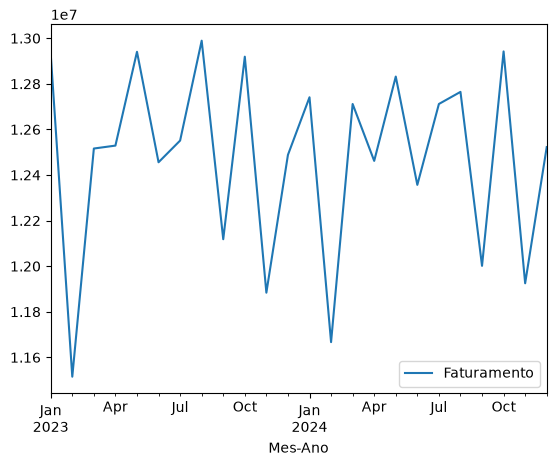

In [42]:

df_tratadov['Mes-Ano'] = df_tratadov['Data'].dt.to_period('M') #cria uma nova coluna Mes-Ano com base na coluna Data, no formato Mês-Ano
df_vendas_mes = df_tratadov[['Mes-Ano', 'Faturamento']].groupby('Mes-Ano').sum() #agrupa por Mes-Ano e soma o Faturamento


df_vendas_mes.plot()

display(df_vendas_mes)